In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("UK Police") \
    .getOrCreate()

sc = spark.sparkContext

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/08 17:30:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
df_final = spark.read.parquet("data/processed_data.parquet").cache()

In [3]:
# Count total records
total_records = df_final.count()
print(f"Total number of search records: {total_records:,}")

# Show schema to understand available features
df_final.printSchema()

# Display a sample of the data
df_final.limit(5).toPandas()

Total number of search records: 1,403,329
root
 |-- age: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- law: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- dayofyear: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- ethnicity: string (nullable = true)
 |-- search_type: string (nullable = true)
 |-- reason: string (nullable = true)
 |-- police_force: string (nullable = true)
 |-- legal_action_taken: integer (nullable = true)



,age,gender,law,year,timestamp,dayofyear,dayofweek,hour,month,ethnicity,search_type,reason,police_force,legal_action_taken
0,10-17,Male,Misuse of Drugs Act 1971 (section 23),2025,2025-10-16 23:59:57,289,5,23,10,White,Person search,Controlled drugs,avon-and-somerset,0
1,18-24,Male,Unknown,2025,2025-10-28 17:06:01,301,3,17,10,Unknown,Person search,Unknown,avon-and-somerset,0
2,Unknown,Unknown,Firearms Act 1968 (section 47),2025,2025-10-22 00:35:59,294,3,0,10,Black,Person search,Firearms,avon-and-somerset,0
3,10-17,Male,Police and Criminal Evidence Act 1984 (section 1),2025,2025-10-23 17:36:34,296,5,17,10,Asian,Person search,Offensive weapons,avon-and-somerset,1
4,10-17,Male,Police and Criminal Evidence Act 1984 (section 1),2025,2025-10-07 21:53:17,280,3,21,10,White,Person search,Offensive weapons,avon-and-somerset,0


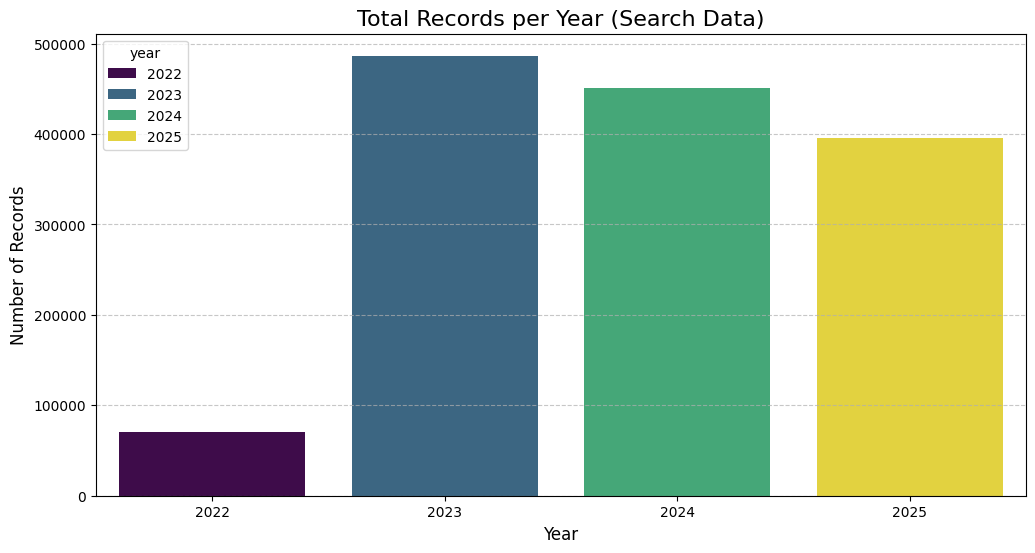

In [4]:
# 1. Filter out nulls (if any) and group by year
yearly_counts = (df_final
                 .filter(F.col("year").isNotNull())
                 .groupBy("year")
                 .count()
                 .orderBy("year"))

# 2. Convert the small aggregated result to Pandas for plotting
pdf = yearly_counts.toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=pdf, 
    x="year",  
    y="count", 
    palette="viridis", 
    hue="year", 
    legend=True
)
# Add labels and title
plt.title('Total Records per Year (Search Data)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Data Processing

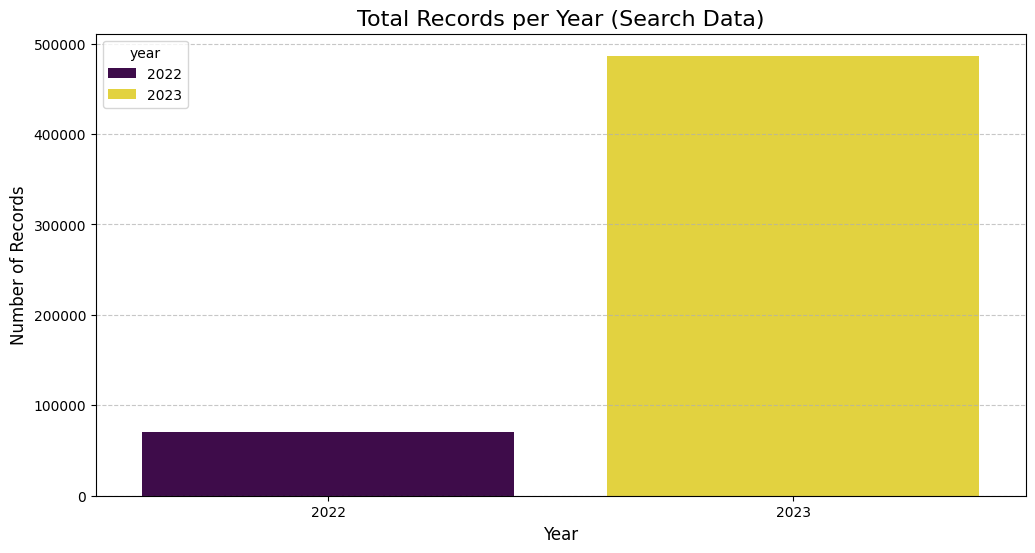

In [5]:
# 1. Filter out nulls (if any) and group by year
yearly_counts = (
    df_final
    .filter(F.col("year") < 2024)
    .groupBy("year")
    .count()
    .orderBy("year")
)

# 2. Convert the small aggregated result to Pandas for plotting
pdf = yearly_counts.toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=pdf, 
    x="year",  
    y="count", 
    palette="viridis", 
    hue="year", 
    legend=True
)
# Add labels and title
plt.title('Total Records per Year (Search Data)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Models training

In [6]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml import Pipeline
from dateutil.relativedelta import relativedelta
import time

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

In [7]:
years = sorted(
    df_final.select("year").distinct().rdd.map(lambda r: r.year).collect()
)

print(years[1:])

[Stage 24:>                                                         (0 + 1) / 1]

[2023, 2024, 2025]


In [ ]:
root
 |-- age: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- law: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- dayofyear: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- ethnicity: string (nullable = true)
 |-- search_type: string (nullable = true)
 |-- reason: string (nullable = true)
 |-- police_force: string (nullable = true)
 |-- legal_action_taken: integer (nullable = true)

In [15]:
categorical_cols = ["age", "gender", "law", "ethnicity", "search_type", "reason", "police_force"]
numeric_cols = ["hour", "month", "dayofweek", "dayofyear"]
feature_cols = [f"{col}_idx" for col in categorical_cols] + numeric_cols

In [24]:
def train_dt(
    train_df,
    categorical_cols,
    numeric_cols,
    feature_cols
):
    # 1. String Indexers
    indexers = [
        StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep") 
        for col in categorical_cols
    ]
    
    # 2. Vector Assembler
    assembler = VectorAssembler(
        inputCols=feature_cols, 
        outputCol="features",
        handleInvalid="keep"
    )
    
    # 3. Decision Tree Estimator
    dt = DecisionTreeClassifier(
        labelCol="legal_action_taken", 
        featuresCol="features", 
        maxDepth=10, 
        maxBins=128,
        minInstancesPerNode=5,
        impurity="gini",
        seed=42
    )
    
    # 4. Construct the Pipeline
    pipeline = Pipeline(stages=indexers + [assembler, dt])
    
    # 5. Evaluator
    evaluator = BinaryClassificationEvaluator(
        rawPredictionCol='rawPrediction',  # Changed from 'prediction'
        labelCol='legal_action_taken'
    )
    
    # 8. Fit with error handling
    try:
        print("Starting Pipeline Training with Temporal Cross-Validation...")
        start_time = time.time()
        
        # This will call your custom _kFold logic internally
        trained_pipeline = pipeline.fit(train_df)
        
        total_time = time.time() - start_time
        print(f"Pipeline fitting complete. Total time: {total_time:.2f} seconds.")
        
    except Exception as e:
        print(f"Error during fitting: {e}")
        # Additional debugging
        print("\nDataset sample:")
        df_final.select("legal_action_taken", "timestamp", *categorical_cols[:3]).show(5)
        raise
        
    return trained_pipeline

In [25]:
def show_importances(
    dt_model,
    categorical_cols,
    numeric_cols,
    feature_names
):  
    feature_importances = dt_model.featureImportances.toArray()
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)
    
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE RANKING".center(60))
    print("="*60)
    print(importance_df.to_string(index=False))
    print("="*60)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=importance_df, 
        x="Importance", 
        y="Feature", 
        hue="Feature",   
        palette="viridis", 
        legend=False
    )
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title('Feature Importance - Decision Tree', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('media/images/feature_importance_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    
    # Estadísticas adicionales
    print(f"\nTotal features: {len(feature_names)}")
    print(f"Top feature: {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']:.4f})")
    print(f"Top 5 features account for: {importance_df.head(5)['Importance'].sum():.2%} of total importance")
    
    importance_df.to_csv('media/results/feature_importance.csv', index=False)
    print("\n✓ Feature importance saved to 'feature_importance.csv'")

In [28]:
def calculate_metrics(
    trained_pipeline,
    test_df
):
    
    # 2. Prepare the test dataset (apply the same transformations)
    print(f"Test data size: {test_df.count()}")
    
    # 3. Make predictions
    predictions = trained_pipeline.transform(test_df)
    
    # 4. Show some predictions
    print("\nSample predictions:")
    predictions.select("legal_action_taken", "prediction", "probability").show(10, truncate=False)
    
    # 5. Evaluate metrics
    
    # --- Binary Classification Metrics (AUC-ROC, AUC-PR) ---
    binary_evaluator = BinaryClassificationEvaluator(
        labelCol="legal_action_taken",
        rawPredictionCol="rawPrediction"
    )
    
    auc = binary_evaluator.evaluate(predictions, {binary_evaluator.metricName: "areaUnderROC"})
    auc_pr = binary_evaluator.evaluate(predictions, {binary_evaluator.metricName: "areaUnderPR"})
    
    print(f"\nArea Under ROC Curve (AUC-ROC): {auc:.4f}")
    print(f"Area Under PR Curve (AUC-PR): {auc_pr:.4f}")
    
    # --- Multiclass Metrics (Accuracy, F1, Precision, Recall) ---
    # CORRECCIÓN: Usamos MulticlassClassificationEvaluator aquí
    multiclass_evaluator = MulticlassClassificationEvaluator(
        labelCol="legal_action_taken",
        predictionCol="prediction"
    )
    
    accuracy = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "accuracy"})
    precision = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedPrecision"})
    recall = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedRecall"})
    f1 = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "f1"})
    
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # 6. Confusion Matrix (Plotting Normalized)
    print("\nConfusion Matrix (Raw Counts):")
    # We calculate counts in Spark
    conf_matrix_spark = predictions.groupBy("legal_action_taken", "prediction").count()
    conf_matrix_spark.orderBy("legal_action_taken", "prediction").show()
    
    # Convert to Pandas for plotting
    cm_pd = conf_matrix_spark.toPandas()
    
    # Create a pivot table: Index=Actual, Columns=Predicted
    cm_pivot = cm_pd.pivot(index='legal_action_taken', columns='prediction', values='count').fillna(0)
    # Sort index/columns to ensure order 0, 1...
    cm_pivot = cm_pivot.sort_index(axis=0).sort_index(axis=1)
    
    # Normalize by row (True Label) to get percentages
    cm_normalized = cm_pivot.div(cm_pivot.sum(axis=1), axis=0)
    
    # Plot using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=True)
    plt.title('Normalized Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig("media/images/confusion_matrix_weighted.png")
    plt.show()
    
    # 7. Metrics by class
    print("\nMetrics by class:")
    for label in [0, 1]:
        tp = predictions.filter((F.col("legal_action_taken") == label) & (F.col("prediction") == label)).count()
        fp = predictions.filter((F.col("legal_action_taken") != label) & (F.col("prediction") == label)).count()
        fn = predictions.filter((F.col("legal_action_taken") == label) & (F.col("prediction") != label)).count()
        
        precision_class = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall_class = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_class = 2 * (precision_class * recall_class) / (precision_class + recall_class) if (precision_class + recall_class) > 0 else 0
        
        print(f"\nClass {label}:")
        print(f"  Precision: {precision_class:.4f}")
        print(f"  Recall: {recall_class:.4f}")
        print(f"  F1-Score: {f1_class:.4f}")
        print(f"  Support: {tp + fn}")

# Unit years

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 14.71 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         age_idx    0.383143
police_force_idx    0.347451
 search_type_idx    0.072220
      reason_idx    0.059314
         law_idx    0.047371
       dayofyear    0.026320
            hour    0.021911
      gender_idx    0.019720
   ethnicity_idx    0.012104
       dayofweek    0.008739
           month    0.001707


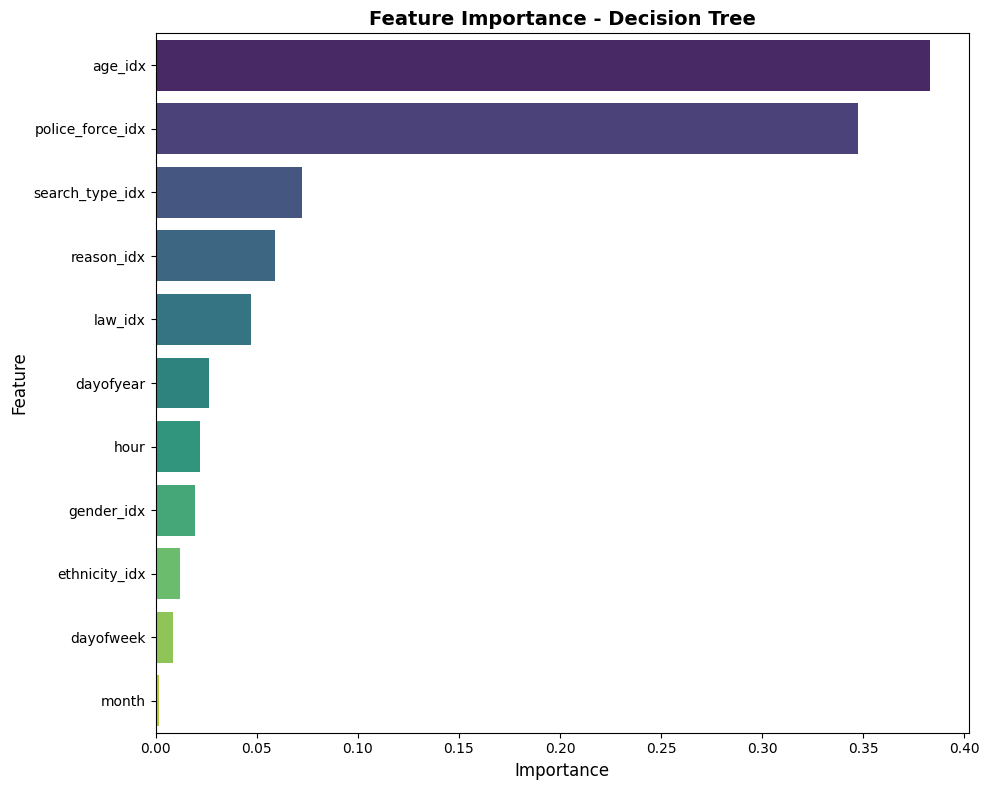


Total features: 11
Top feature: age_idx (0.3831)
Top 5 features account for: 90.95% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 99378

Sample predictions:


+------------------+----------+----------------------------------------+
|legal_action_taken|prediction|probability                             |
+------------------+----------+----------------------------------------+
|0                 |0.0       |[0.8346572521329803,0.16534274786701972]|
|0                 |0.0       |[0.9265033407572383,0.07349665924276169]|
|0                 |0.0       |[0.8185613829475534,0.18143861705244652]|
|0                 |0.0       |[0.8257261410788381,0.17427385892116182]|
|0                 |0.0       |[0.6666666666666666,0.3333333333333333] |
|0                 |0.0       |[0.9087301587301587,0.09126984126984126]|
|0                 |0.0       |[0.7501898253606681,0.2498101746393318] |
|0                 |0.0       |[0.875,0.125]                           |
|0                 |0.0       |[0.875,0.125]                           |
|0                 |0.0       |[0.7668505636843368,0.23314943631566323]|
+------------------+----------+--------------------


Area Under ROC Curve (AUC-ROC): 0.5458
Area Under PR Curve (AUC-PR): 0.2906



Accuracy: 0.7298
Weighted Precision: 0.6597
Weighted Recall: 0.7298
F1 Score: 0.6299

Confusion Matrix (Raw Counts):


+------------------+----------+-----+
|legal_action_taken|prediction|count|
+------------------+----------+-----+
|                 0|       0.0|71796|
|                 0|       1.0|  869|
|                 1|       0.0|25982|
|                 1|       1.0|  731|
+------------------+----------+-----+



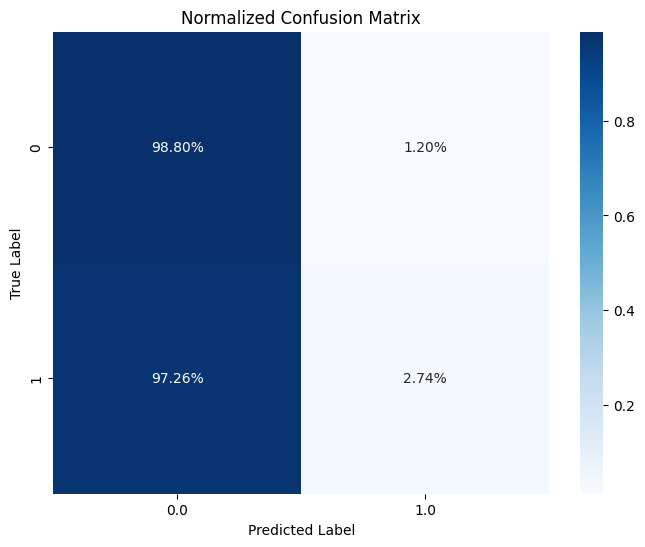


Metrics by class:



Class 0:
  Precision: 0.7343
  Recall: 0.9880
  F1-Score: 0.8425
  Support: 72665



Class 1:
  Precision: 0.4569
  Recall: 0.0274
  F1-Score: 0.0516
  Support: 26713
Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 17.03 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
police_force_idx    0.349322
         age_idx    0.323028
      gender_idx    0.073262
      reason_idx    0.069069
 search_type_idx    0.061590
         law_idx    0.034969
       dayofyear    0.033410
            hour    0.023429
   ethnicity_idx    0.014674
       dayofweek    0.011955
           month    0.005293


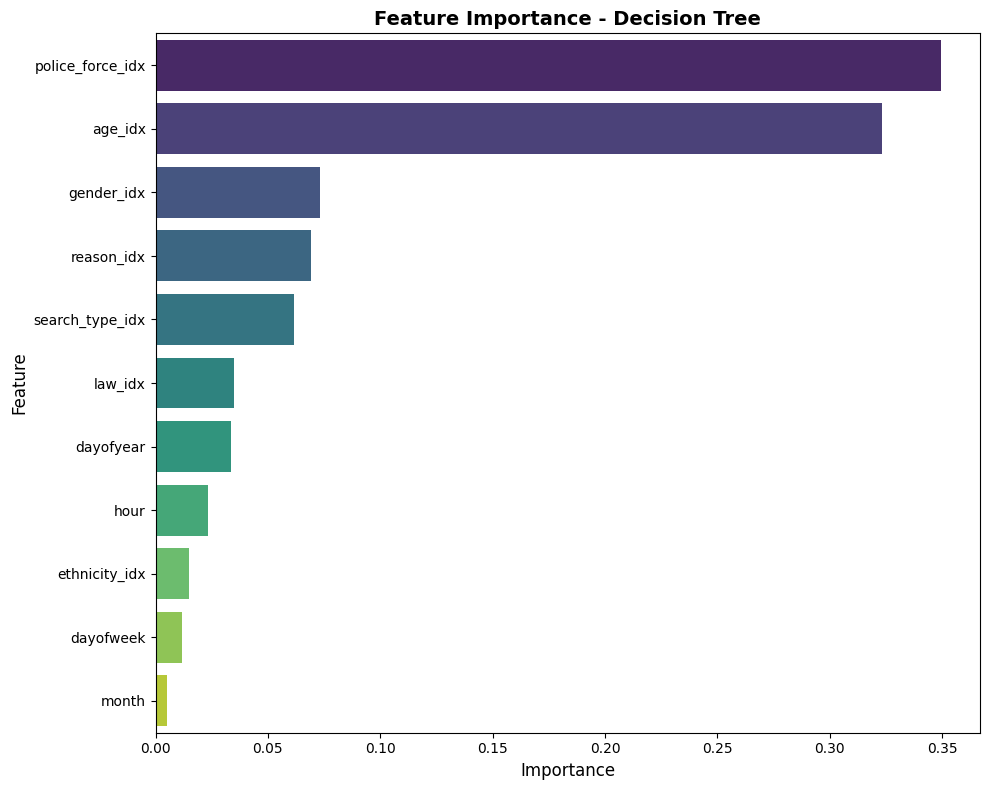


Total features: 11
Top feature: police_force_idx (0.3493)
Top 5 features account for: 87.63% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 80834

Sample predictions:


+------------------+----------+----------------------------------------+
|legal_action_taken|prediction|probability                             |
+------------------+----------+----------------------------------------+
|0                 |0.0       |[0.9326424870466321,0.06735751295336788]|
|1                 |0.0       |[0.9328859060402684,0.06711409395973154]|
|0                 |0.0       |[0.8557692307692307,0.14423076923076922]|
|0                 |0.0       |[0.8557692307692307,0.14423076923076922]|
|0                 |0.0       |[0.9688473520249221,0.03115264797507788]|
|1                 |0.0       |[0.7803928508228632,0.21960714917713678]|
|0                 |0.0       |[0.5937149270482603,0.4062850729517396] |
|0                 |0.0       |[0.7803928508228632,0.21960714917713678]|
|0                 |0.0       |[0.6980810234541578,0.3019189765458422] |
|0                 |0.0       |[0.7803928508228632,0.21960714917713678]|
+------------------+----------+--------------------


Area Under ROC Curve (AUC-ROC): 0.5317
Area Under PR Curve (AUC-PR): 0.3011



Accuracy: 0.7140
Weighted Precision: 0.6580
Weighted Recall: 0.7140
F1 Score: 0.6219

Confusion Matrix (Raw Counts):


+------------------+----------+-----+
|legal_action_taken|prediction|count|
+------------------+----------+-----+
|                 0|       0.0|56395|
|                 0|       1.0| 1321|
|                 1|       0.0|21796|
|                 1|       1.0| 1322|
+------------------+----------+-----+



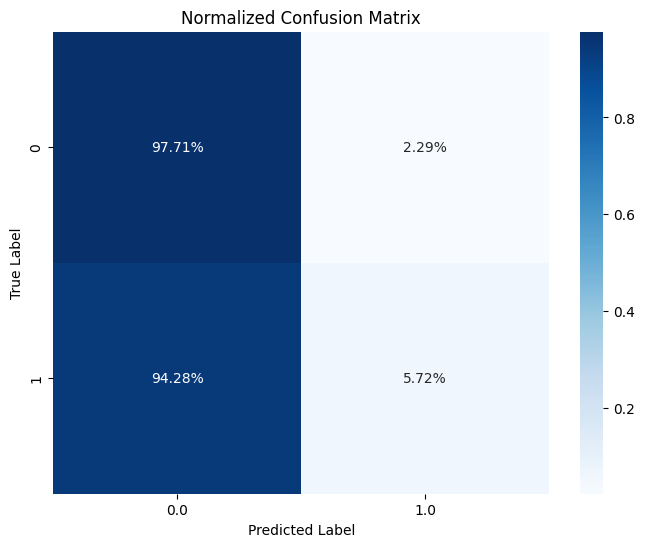


Metrics by class:



Class 0:
  Precision: 0.7212
  Recall: 0.9771
  F1-Score: 0.8299
  Support: 57716



Class 1:
  Precision: 0.5002
  Recall: 0.0572
  F1-Score: 0.1026
  Support: 23118
Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 13.77 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         law_idx    0.314784
         age_idx    0.313513
police_force_idx    0.180784
      reason_idx    0.059129
      gender_idx    0.053028
 search_type_idx    0.028996
            hour    0.020276
       dayofyear    0.013920
   ethnicity_idx    0.005838
       dayofweek    0.005256
           month    0.004475


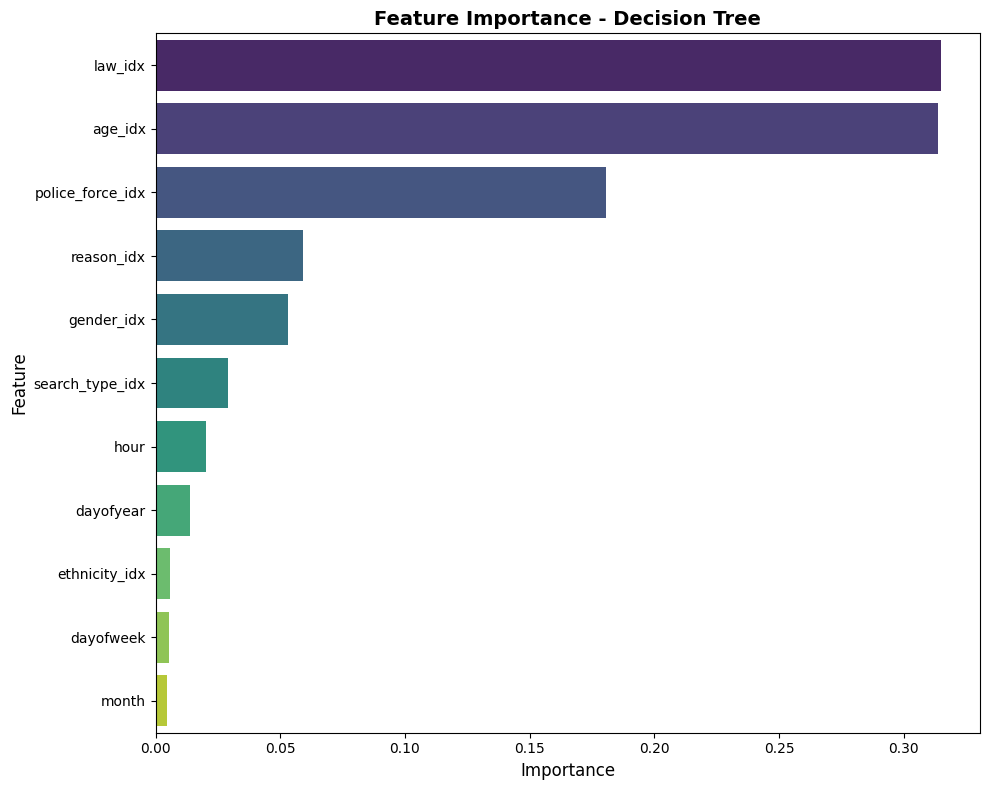


Total features: 11
Top feature: law_idx (0.3148)
Top 5 features account for: 92.12% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 71375

Sample predictions:


+------------------+----------+-----------------------------------------+
|legal_action_taken|prediction|probability                              |
+------------------+----------+-----------------------------------------+
|0                 |0.0       |[0.9090909090909091,0.09090909090909091] |
|0                 |0.0       |[0.9977414871438499,0.002258512856150104]|
|0                 |0.0       |[0.9977414871438499,0.002258512856150104]|
|0                 |0.0       |[0.9153439153439153,0.08465608465608465] |
|1                 |1.0       |[0.0,1.0]                                |
|1                 |0.0       |[0.6814046061984645,0.3185953938015354]  |
|0                 |0.0       |[0.7966255678131083,0.20337443218689163] |
|1                 |0.0       |[0.6814046061984645,0.3185953938015354]  |
|0                 |0.0       |[0.6552262090483619,0.34477379095163807] |
|0                 |0.0       |[0.6814046061984645,0.3185953938015354]  |
+------------------+----------+-------


Area Under ROC Curve (AUC-ROC): 0.6122
Area Under PR Curve (AUC-PR): 0.3465



Accuracy: 0.7203
Weighted Precision: 0.6683
Weighted Recall: 0.7203
F1 Score: 0.6297

Confusion Matrix (Raw Counts):


+------------------+----------+-----+
|legal_action_taken|prediction|count|
+------------------+----------+-----+
|                 0|       0.0|50220|
|                 0|       1.0| 1104|
|                 1|       0.0|18863|
|                 1|       1.0| 1188|
+------------------+----------+-----+



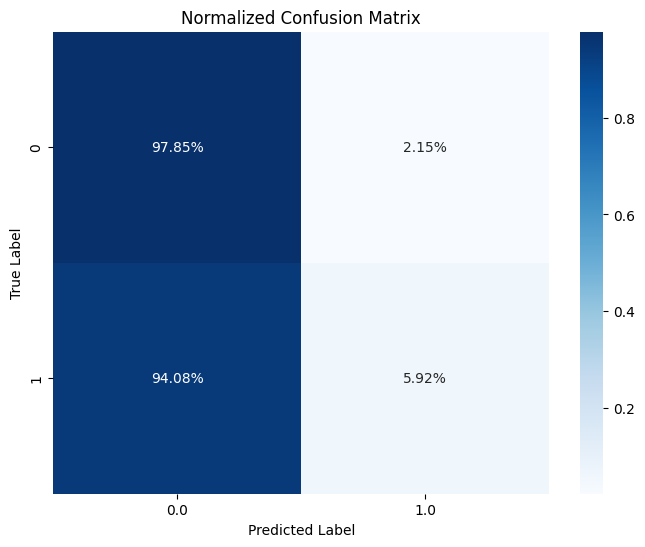


Metrics by class:



Class 0:
  Precision: 0.7270
  Recall: 0.9785
  F1-Score: 0.8342
  Support: 51324


[Stage 1093:>                                                       (0 + 4) / 4]


Class 1:
  Precision: 0.5183
  Recall: 0.0592
  F1-Score: 0.1063
  Support: 20051


In [29]:
fractions = {
    2022: 0.8,
    2023: 0.8,
    2024: 0.8,
    2025: 0.8
}

# Muestreo estratificado
train_df = df_final.sampleBy("year", fractions, seed=42)

# El test set son los registros que NO están en train
test_df = df_final.join(train_df, on=df_final.columns, how="left_anti")

for year in [2023, 2024, 2025]:
    if year == 2023:
        train_df_objective = (
            train_df.filter(
                F.col("year") <= year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") <= year
            )
        )
    else:
        train_df_objective = (
            train_df.filter(
                F.col("year") == year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") == year
            )
        )
        
    trained_pipeline = train_dt(
        train_df_objective,
        categorical_cols, 
        numeric_cols,
        feature_cols
    )

    trained_model = trained_pipeline.stages[-1]
    
    show_importances(
        trained_model,
        categorical_cols,
        numeric_cols,
        feature_cols
    )

    calculate_metrics(
        trained_pipeline,
        test_df_objective
    )
    